# Práctica 10 LDA

In [ ]:
%pip install pypdf gensim pyldavis wordcloud 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from sklearn.datasets import fetch_20newsgroups
import Stopwords_Copy
import Reglas_Lematizador_Copy
import Preprocesamiento_Copy
from gensim import corpora
from gensim.models import LdaModel
from wordcloud import WordCloud
import matplotlib.pyplot as plt

## Carga de 500 documentos

In [3]:
datos = fetch_20newsgroups(
    subset="all",
    remove=("headers", "footers", "quotes"),
    shuffle=True,
    random_state=42
)

df = pd.DataFrame({
    "texto_original": datos.data,
    "categoria_id": datos.target,
    "categoria": [datos.target_names[i] for i in datos.target]
})

df.head()

,texto_original,categoria_id,categoria
0,\n\nI am sure some bashers of Pens fans are pr...,10,rec.sport.hockey
1,My brother is in the market for a high-perform...,3,comp.sys.ibm.pc.hardware
2,\n\n\n\n\tFinally you said what you dream abou...,17,talk.politics.mideast
3,\nThink!\n\nIt's the SCSI card doing the DMA t...,3,comp.sys.ibm.pc.hardware
4,1) I have an old Jasmine drive which I cann...,4,comp.sys.mac.hardware


## Funciones para limpiar corpus

In [4]:
df["num_palabras_original"] = df["texto_original"].apply(
    Preprocesamiento_Copy.contador_palabras)

In [5]:
df = df[df["num_palabras_original"] >= 50].copy()

df_500 = df.head(500).copy()

df_500.reset_index(drop=True, inplace=True)

df_500.insert(0, "id_documento", range(1, len(df_500) + 1))

## Aplicar limpieza del corpus

In [6]:
df_500["texto_minusculas"] = df_500["texto_original"].apply(
    Preprocesamiento_Copy.to_minusculas)

df_500["tokens"] = df_500["texto_minusculas"].apply(
    Preprocesamiento_Copy.tokenizador)

df_500["tokens_lematizados"] = df_500["tokens"].apply(
    Preprocesamiento_Copy.lematizador)

df_500["texto_limpio"] = df_500["tokens_lematizados"].apply(
    lambda tokens: " ".join(tokens))

df_500["num_tokens_limpios"] = df_500["tokens_lematizados"].apply(
    Preprocesamiento_Copy.contar_lista)

Eliminar documentos vacíos

In [7]:
df_500 = df_500[df_500["num_tokens_limpios"] > 0].copy()

df_500.reset_index(drop=True, inplace=True)

df_500["id_documento"] = range(1, len(df_500) + 1)

Corpus limpio

In [8]:
df_500.to_csv(
    "corpus_500_documentos_limpio.csv",
    index=False,
    encoding="utf-8-sig")

print(df_500[["id_documento", "categoria", "num_palabras_original",
              "num_tokens_limpios", "texto_limpio"]].head())

   id_documento                 categoria  num_palabras_original  \
0             1          rec.sport.hockey                    137   
1             2  comp.sys.ibm.pc.hardware                     53   
2             3     talk.politics.mideast                    241   
3             4  comp.sys.ibm.pc.hardware                    144   
4             5     comp.sys.mac.hardware                    125   

   num_tokens_limpios                                       texto_limpio  
0                  97  i be sure some basher pen fan pretty confus ab...  
1                  39  my broth market high performance video car sup...  
2                 177  final you say what you dream about mediterrane...  
3                  83  think s scsi car do dma transfer not disk scsi...  
4                  74  i ol jasmine drive which i cannot use my new s...  


## Modelado de Tópicos con LDA
Parámetros 

In [ ]:
N_TOPICS = 5    # numero de temas a identificar
M_WORDS  = 50   # palabras por nube de palabras

Preparar diccionario y corpus para Gensim

In [ ]:
tokenized_docs = df_500["tokens_lematizados"].tolist()

diccionario = corpora.Dictionary(tokenized_docs)

diccionario.filter_extremes(no_below=2, no_above=0.9) #elimina palabras que aparecen en menos de 2 documentos  o en más del 90% de documentos 

corpus_bow = [diccionario.doc2bow(doc) for doc in tokenized_docs]

print(f"Vocabulario: {len(diccionario)} términos únicos")
print(f"Documentos:  {len(corpus_bow)}")

Vocabulario: 4701 términos únicos
Documentos:  500


Entrenar modelo LDA

In [ ]:
lda_model = LdaModel(
    corpus=corpus_bow,
    id2word=diccionario,
    num_topics=N_TOPICS,
    random_state=42,
    passes=10,
    alpha="auto",
    per_word_topics=True
)

print("Tópicos encontrados:\n") #que tan probable es que cada palabra pertenezca a cada tópico
for idx, topico in lda_model.print_topics(num_words=10):
    print(f"  Tópico {idx+1}: {topico}\n")

Tópicos encontrados:

  Tópico 1: 0.013*"do" + 0.007*"you" + 0.007*"key" + 0.007*"will" + 0.006*"if" + 0.006*"det" + 0.006*"nyr" + 0.006*"chip" + 0.005*"woul" + 0.005*"us"

  Tópico 2: 0.032*"i" + 0.009*"you" + 0.009*"s" + 0.006*"if" + 0.006*"t" + 0.006*"be" + 0.005*"not" + 0.005*"will" + 0.005*"woul" + 0.005*"my"

  Tópico 3: 0.047*"i" + 0.017*"you" + 0.011*"be" + 0.010*"t" + 0.009*"s" + 0.009*"not" + 0.009*"we" + 0.008*"do" + 0.008*"what" + 0.007*"if"

  Tópico 4: 0.022*"you" + 0.020*"i" + 0.017*"not" + 0.013*"be" + 0.011*"s" + 0.010*"t" + 0.008*"they" + 0.008*"if" + 0.008*"your" + 0.007*"he"

  Tópico 5: 0.024*"i" + 0.012*"be" + 0.010*"s" + 0.009*"t" + 0.009*"they" + 0.009*"you" + 0.008*"not" + 0.008*"we" + 0.005*"if" + 0.005*"will"



Distribución de tópicos por documento

In [ ]:
topico_dominante = [] #tomar el topico mas domimante para cada documento
for bow in corpus_bow:
    distribucion = lda_model.get_document_topics(bow)
    if distribucion:
        topico_dom = max(distribucion, key=lambda x: x[1])[0]
    else:
        topico_dom = -1
    topico_dominante.append(topico_dom + 1)  

df_500["topico_dominante"] = topico_dominante

print(df_500[["id_documento", "categoria", "topico_dominante"]].head(10))

   id_documento                 categoria  topico_dominante
0             1          rec.sport.hockey                 4
1             2  comp.sys.ibm.pc.hardware                 2
2             3     talk.politics.mideast                 4
3             4  comp.sys.ibm.pc.hardware                 2
4             5     comp.sys.mac.hardware                 3
5             6           sci.electronics                 5
6             7          rec.sport.hockey                 5
7             8          rec.sport.hockey                 3
8             9        talk.religion.misc                 4
9            10        talk.religion.misc                 4


Palabras de cada topico

In [17]:

print(f"{'Tópico':<10} {'Palabras más representativas'}")
for i in range(N_TOPICS):
    palabras = [palabra for palabra, peso in lda_model.show_topic(i, topn=20)]
    print(f"Tópico {i+1:<5} {', '.join(palabras)}")

Tópico     Palabras más representativas
Tópico 1     do, you, key, will, if, det, nyr, chip, woul, us, s, i, not, bo, can, use, la, when, make, wat
Tópico 2     i, you, s, if, t, be, not, will, woul, my, us, car, about, print, new, system, bit, so, x, me
Tópico 3     i, you, be, t, s, not, we, do, what, if, there, any, my, woul, know, think, us, some, will, about
Tópico 4     you, i, not, be, s, t, they, if, your, he, go, there, say, no, will, who, we, people, what, so
Tópico 5     i, be, s, t, they, you, not, we, if, will, l, about, woul, my, year, some, do, out, us, go


Nube de palabras por tópico

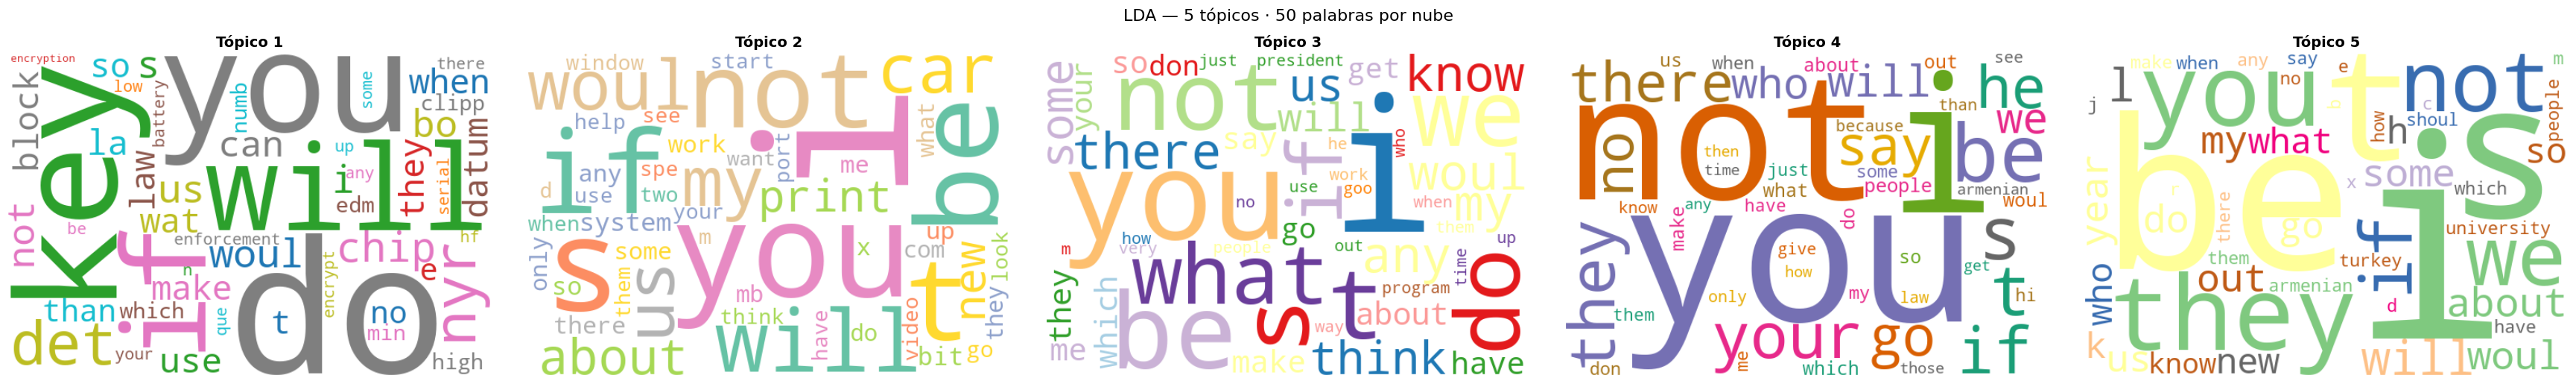

In [ ]:
fig, axes = plt.subplots(1, N_TOPICS, figsize=(7 * N_TOPICS, 5))

if N_TOPICS == 1:
    axes = [axes]

colormaps = ["tab10", "Set2", "Paired", "Dark2", "Accent"]

for i, ax in enumerate(axes):
    #M palabras más probables de un tópico con su peso
    palabras_pesos = dict(lda_model.show_topic(i, topn=M_WORDS))

    nube = WordCloud(
        width=600,
        height=400,
        background_color="white",
        colormap=colormaps[i % len(colormaps)],
        max_words=M_WORDS
    ).generate_from_frequencies(palabras_pesos)

    ax.imshow(nube, interpolation="bilinear")
    ax.set_title(f"Tópico {i+1}", fontsize=14, fontweight="bold")
    ax.axis("off")

plt.suptitle(
    f"LDA — {N_TOPICS} tópicos · {M_WORDS} palabras por nube",
    fontsize=16, y=1.02
)
plt.tight_layout()
plt.show()